In [1]:
# Install necessary libraries
!pip install pandas transformers matplotlib seaborn torch scipy

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from scipy.special import softmax
import torch

# Load pre-trained sentiment analysis model
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [3]:
# Create dataset of 5 customer reviews for iCreativez
reviews_data = {
    'review_id': [1, 2, 3, 4, 5],
    'customer_review': [
        "iCreativez delivered an amazing website for my business! The team was professional and the design exceeded my expectations.",
        "The mobile app development service was just okay. Communication could have been better, but the final product works fine.",
        "Absolutely terrible experience! The project was delayed by months and the customer support was unresponsive.",
        "Great service! They built a custom CRM that perfectly fits our needs. Highly recommend iCreativez for digital solutions.",
        "The logo design was decent, but I expected more creative options. Not bad, but not great either."
    ]
}

# Convert to DataFrame
df = pd.DataFrame(reviews_data)
print("Customer Reviews Dataset:")
df

Customer Reviews Dataset:


,review_id,customer_review
0,1,iCreativez delivered an amazing website for my...
1,2,The mobile app development service was just ok...
2,3,Absolutely terrible experience! The project wa...
3,4,Great service! They built a custom CRM that pe...
4,5,"The logo design was decent, but I expected mor..."


In [4]:
# Function to analyze sentiment of a single text
def analyze_sentiment(text):
    # Tokenize input
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)

    # Get model predictions
    with torch.no_grad():
        output = model(**encoded_input)

    # Apply softmax to get probabilities
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)

    # Map labels (model uses: 0=Negative, 1=Neutral, 2=Positive)
    labels = ['Negative', 'Neutral', 'Positive']

    # Return dictionary with sentiment scores
    return {labels[i]: float(scores[i]) for i in range(len(labels))}

# Apply sentiment analysis to all reviews
sentiment_results = []
for review in df['customer_review']:
    result = analyze_sentiment(review)
    sentiment_results.append(result)

# Extract primary sentiment (the one with highest score)
df['sentiment_scores'] = sentiment_results
df['sentiment'] = df['sentiment_scores'].apply(lambda x: max(x, key=x.get))

# Display results
print("\nSentiment Analysis Results:")
df[['review_id', 'customer_review', 'sentiment']]


Sentiment Analysis Results:


,review_id,customer_review,sentiment
0,1,iCreativez delivered an amazing website for my...,Positive
1,2,The mobile app development service was just ok...,Positive
2,3,Absolutely terrible experience! The project wa...,Negative
3,4,Great service! They built a custom CRM that pe...,Positive
4,5,"The logo design was decent, but I expected mor...",Neutral


In [5]:
# Display detailed results with confidence scores
print("\nDetailed Results with Confidence Scores:\n")
for idx, row in df.iterrows():
    print(f"Review {row['review_id']}:")
    print(f"Text: {row['customer_review'][:100]}...")
    print(f"Sentiment: {row['sentiment']}")
    print(f"Confidence: {row['sentiment_scores'][row['sentiment']]:.2%}")
    print("-" * 50)


Detailed Results with Confidence Scores:

Review 1:
Text: iCreativez delivered an amazing website for my business! The team was professional and the design ex...
Sentiment: Positive
Confidence: 98.78%
--------------------------------------------------
Review 2:
Text: The mobile app development service was just okay. Communication could have been better, but the fina...
Sentiment: Positive
Confidence: 93.88%
--------------------------------------------------
Review 3:
Text: Absolutely terrible experience! The project was delayed by months and the customer support was unres...
Sentiment: Negative
Confidence: 95.44%
--------------------------------------------------
Review 4:
Text: Great service! They built a custom CRM that perfectly fits our needs. Highly recommend iCreativez fo...
Sentiment: Positive
Confidence: 98.23%
--------------------------------------------------
Review 5:
Text: The logo design was decent, but I expected more creative options. Not bad, but not great either....
S

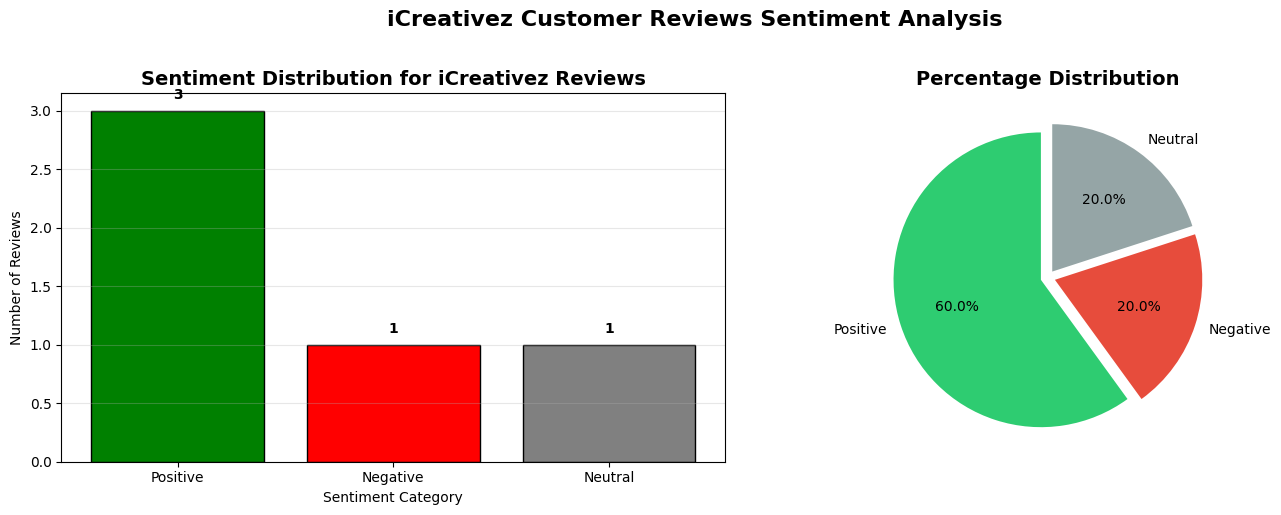

In [6]:
# Create visualization of sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sentiment_counts = df['sentiment'].value_counts()
colors = {'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}
bar_colors = [colors[s] for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution for iCreativez Reviews', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Number of Reviews')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Pie chart
colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.suptitle('iCreativez Customer Reviews Sentiment Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Generate summary statistics
print("\n" + "="*50)
print("SENTIMENT ANALYSIS SUMMARY REPORT")
print("="*50)
print(f"Total Reviews Analyzed: {len(df)}")
print(f"Positive Reviews: {(df['sentiment'] == 'Positive').sum()}")
print(f"Neutral Reviews: {(df['sentiment'] == 'Neutral').sum()}")
print(f"Negative Reviews: {(df['sentiment'] == 'Negative').sum()}")
print(f"Overall Satisfaction Rate: {(df['sentiment'] == 'Positive').sum() / len(df) * 100:.1f}%")
print("="*50)

# Provide recommendations based on results
print("\nKEY INSIGHTS:")
positive_count = (df['sentiment'] == 'Positive').sum()
negative_count = (df['sentiment'] == 'Negative').sum()

if positive_count > negative_count:
    print("✅ Customers are generally satisfied with iCreativez services")
elif negative_count > positive_count:
    print("⚠️ Customer feedback indicates areas needing improvement")
else:
    print("📊 Mixed customer feedback - balanced sentiment distribution")

# Show problematic reviews if any
negative_reviews = df[df['sentiment'] == 'Negative']
if len(negative_reviews) > 0:
    print(f"\n⚠️ Action Items: Review {len(negative_reviews)} negative feedback(s) for follow-up")


SENTIMENT ANALYSIS SUMMARY REPORT
Total Reviews Analyzed: 5
Positive Reviews: 3
Neutral Reviews: 1
Negative Reviews: 1
Overall Satisfaction Rate: 60.0%

KEY INSIGHTS:
✅ Customers are generally satisfied with iCreativez services

⚠️ Action Items: Review 1 negative feedback(s) for follow-up
